In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow and Keras ready!")

TensorFlow and Keras ready!


In [3]:
def get_stock_data(ticker, period="1y"):
    stock = yf.Ticker(ticker)
    data = stock.history(period=period)
    data = data[["Close"]]
    data.index = data.index.tz_localize(None)
    return data

df = get_stock_data("AAPL", period="1y")
print(f"Data Shape: {df.shape}")
print(df.head())

Data Shape: (251, 1)
                 Close
Date                  
2025-05-01  212.394318
2025-05-02  204.458893
2025-05-05  198.026917
2025-05-06  197.648560
2025-05-07  195.398376


In [4]:
def scale_data(df):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df[["Close"]])
    return scaled_data, scaler

scaled_data, scaler = scale_data(df)
print(f"Scaled Data Shape: {scaled_data.shape}")
print(f"Min: {scaled_data.min():.4f}, Max: {scaled_data.max():.4f}")

Scaled Data Shape: (251, 1)
Min: 0.0000, Max: 1.0000


In [5]:
def create_sequences(scaled_data, sequence_length=60):
    X, y = [], []
    
    for i in range(sequence_length, len(scaled_data)):
        X.append(scaled_data[i-sequence_length:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, y

X, y = create_sequences(scaled_data, sequence_length=60)
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (191, 60, 1)
y Shape: (191,)


In [6]:
def split_data(X, y, split_ratio=0.8):
    split = int(len(X) * split_ratio)
    
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X, y)

Training samples: 152
Testing samples: 39


In [7]:
def build_lstm_model(sequence_length=60):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    
    model.compile(optimizer="adam", loss="mean_squared_error")
    model.summary()
    return model

model = build_lstm_model()

c:\Users\sharm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("Training Complete!")

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.2821 - val_loss: 0.0061
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0599 - val_loss: 0.0250
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0227 - val_loss: 0.0198
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0293 - val_loss: 0.0107
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0143 - val_loss: 0.0060
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0148 - val_loss: 0.0104
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0171 - val_loss: 0.0040
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0132 - val_loss: 0.0046
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0137 - val_loss: 0.0040
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0112 - val_loss: 0.0046
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0129 - val_loss: 0.0052
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0124 - val_loss: 0.0039


In [9]:
def predict(model, X_test, scaler):
    predictions = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions)
    return predictions

predictions = predict(model, X_test, scaler)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Sample Predictions vs Actual:")
for i in range(5):
    print(f"Predicted: ${predictions[i][0]:.2f} | Actual: ${actual[i][0]:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Sample Predictions vs Actual:
Predicted: $265.06 | Actual: $257.46
Predicted: $264.56 | Actual: $259.88
Predicted: $264.05 | Actual: $260.83
Predicted: $263.59 | Actual: $260.81
Predicted: $263.17 | Actual: $255.76


In [10]:
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
mape = np.mean(np.abs((actual - predictions) / actual)) * 100

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): $6.37
Root Mean Squared Error (RMSE): $7.26
Mean Absolute Percentage Error (MAPE): 2.45%


ValueError: x and y must have same first dimension, but have shapes (0,) and (39, 1)

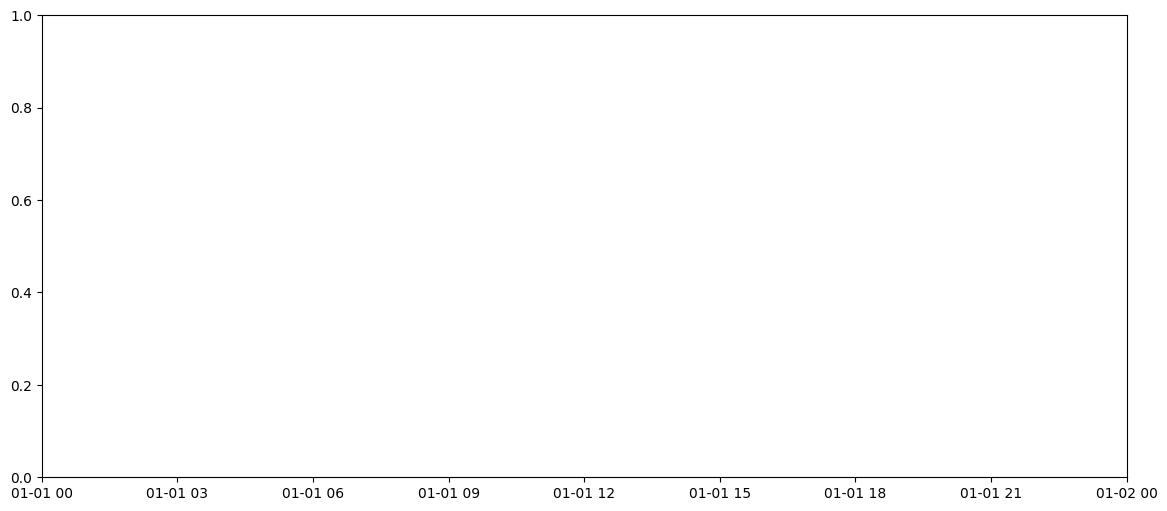

In [11]:
def plot_predictions(df, actual, predictions, ticker):
    train_size = len(df) - len(actual)
    dates = df.index[train_size + 60:]

    plt.figure(figsize=(14, 6))
    plt.plot(dates, actual, color="blue", linewidth=2, label="Actual Price")
    plt.plot(dates, predictions, color="red", linewidth=2, 
             linestyle="--", label="Predicted Price")
    plt.title(f"{ticker} — LSTM Price Prediction vs Actual")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_predictions(df, actual, predictions, "AAPL")

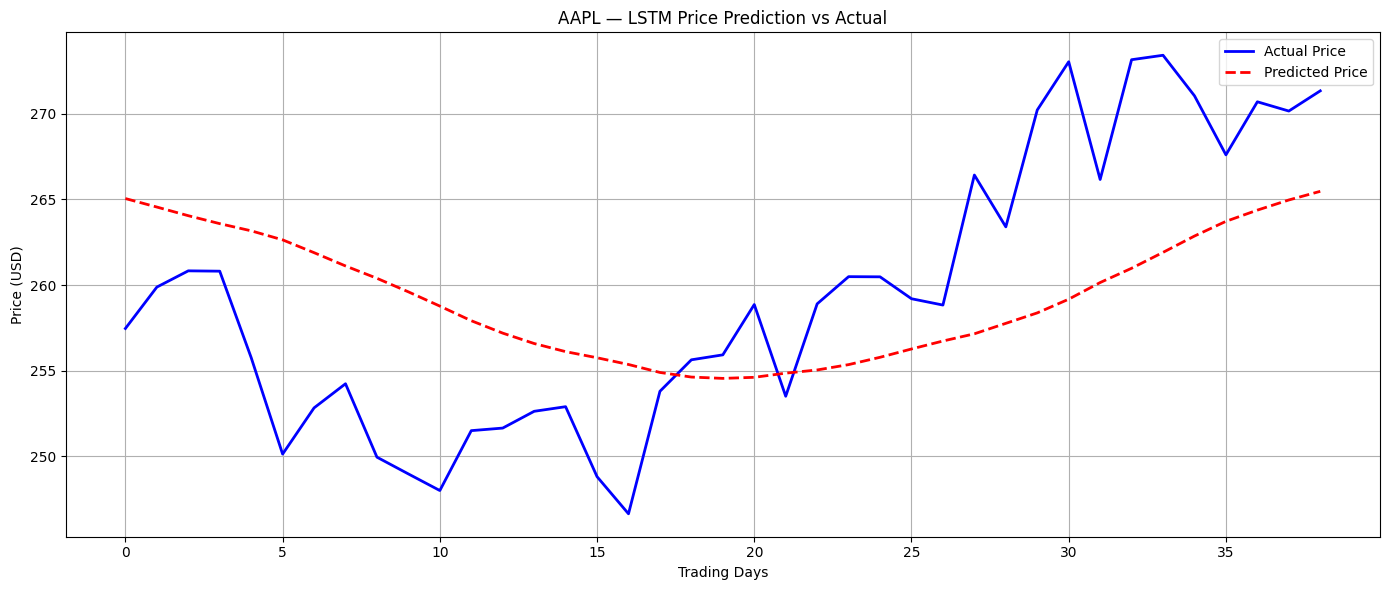

In [12]:
def plot_predictions(actual, predictions, ticker):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, color="blue", linewidth=2, label="Actual Price")
    plt.plot(predictions, color="red", linewidth=2, 
             linestyle="--", label="Predicted Price")
    plt.title(f"{ticker} — LSTM Price Prediction vs Actual")
    plt.xlabel("Trading Days")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_predictions(actual, predictions, "AAPL")